# Metaheuristics Notebook - Telemetry Heart AI

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from app.services.genetic_engine import GeneticEngine
from app.services.pso_engine import PSOEngine

C:\Users\HALO\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load dataset
df = pd.read_csv('../app/data/heart.csv')
X = df.drop('target', axis=1)
y = df['target']

In [3]:
# Genetic Algorithm
print("Running Genetic Algorithm...")
ga = GeneticEngine(n_features=13, population_size=50, generations=20)
ga_result = ga.run(X, y)
print(f"Selected features: {ga_result['feature_names']}")
print(f"N selected: {ga_result['n_selected']}")
print(f"Best fitness: {ga_result['best_fitness']:.4f}")

Running Genetic Algorithm...


Selected features: ['age', 'sex', 'cp', 'chol', 'restecg', 'thalach', 'exang', 'ca', 'thal']
N selected: 9
Best fitness: 0.9180


In [4]:
# PSO
print("\nRunning PSO...")
pso = PSOEngine(n_particles=30, n_iterations=30)
pso_result = pso.run(X, y)
print(f"Best params: {pso_result['best_params']}")
print(f"Best fitness: {pso_result['best_fitness']:.4f}")


Running PSO...


Best params: {'n_estimators': 10, 'max_depth': 14, 'min_samples_split': 10, 'min_samples_leaf': 1}
Best fitness: 0.9345


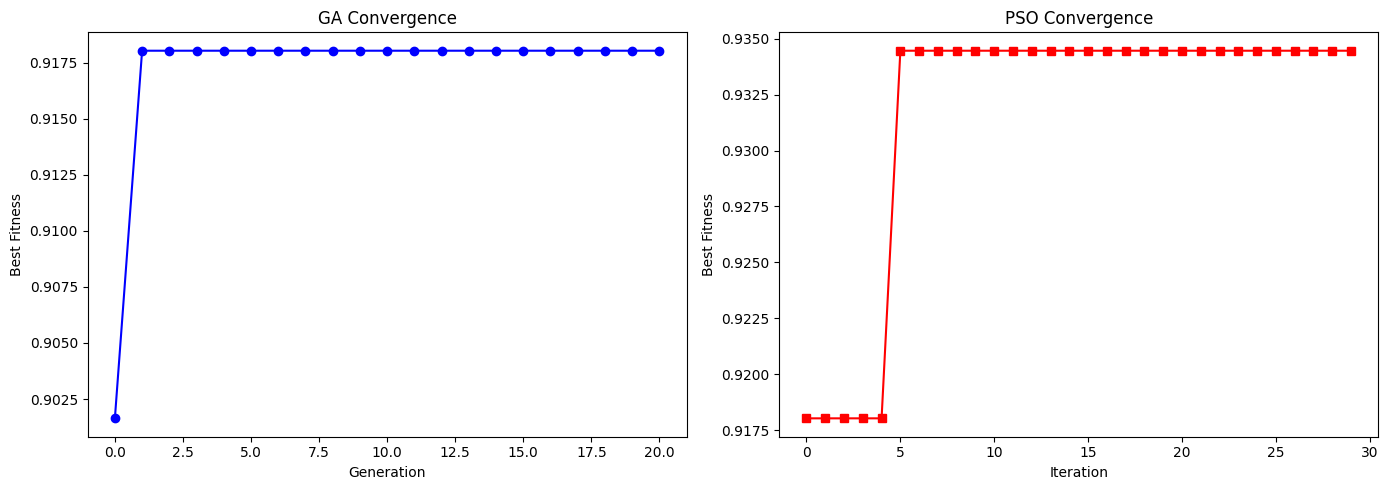

In [5]:
# Convergence plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GA convergence
if ga.history:
    gens = [log['gen'] for log in ga.history if 'gen' in log]
    max_fitness = [log['max'] for log in ga.history if 'max' in log]
    axes[0].plot(gens, max_fitness, 'b-o')
    axes[0].set_title('GA Convergence')
    axes[0].set_xlabel('Generation')
    axes[0].set_ylabel('Best Fitness')

# PSO convergence
if pso.history:
    iters = [h['iteration'] for h in pso.history]
    best_fits = [h['best_fitness'] for h in pso.history]
    axes[1].plot(iters, best_fits, 'r-s')
    axes[1].set_title('PSO Convergence')
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('Best Fitness')

plt.tight_layout()
plt.savefig('../app/data/charts/convergence.png')
plt.show()

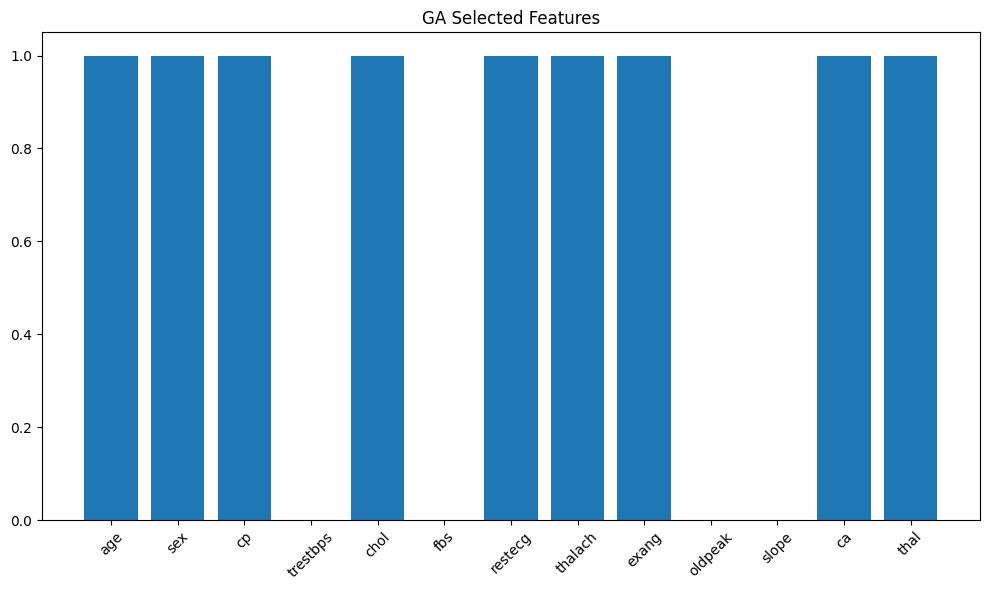

In [6]:
# Feature importance from GA
plt.figure(figsize=(10, 6))
selected = [1 if i in ga_result['selected_features'] else 0 for i in range(13)]
plt.bar(X.columns, selected)
plt.title('GA Selected Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../app/data/charts/ga_features.png')
plt.show()

In [7]:
print("Metaheuristics complete!")

Metaheuristics complete!
